In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Data import

In [1555]:
df = pd.read_csv(
    r'C:\Users\elias\Desktop\JULY 10ALYSTIC NOVA PROJECT\Novapay-fraudulent\data\nova_pay_combined.csv'
)

In [ ]:
df.head() # Display the first 5 rows of the DataFrame

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,is_weekend,transaction_number,minutes_since_last_txn,device_frequency,ip_frequency,customer_avg_amount,customer_max_amount,transactions_last_24h,high_risk_country,currency_mismatch
10232,dcd64b56-3092-4778-a0ce-207d76b282d9,0006f893-10a8-4235-831b-fcae1e3f0140,2023-12-24 15:43:45.573611+00:00,CA,CAD,PHP,web,729.85,540.09,12.06,...,1,1,0.0,1,1,540.09,540.09,1.0,0,1
10386,9ddaf713-8129-44bb-9873-11b1bd5a9228,00147b79-11ed-4f8f-a3af-651778b78dd3,2024-04-12 02:12:31.573611+00:00,US,USD,MXN,web,286.04,286.04,5.88,...,0,1,0.0,1,1,286.04,286.04,1.0,0,1
11314,77c581e1-7e9c-4a5b-bd6a-6649e927d8ca,00668d83-6f9f-4401-9a0f-04f94140abb6,2025-10-15 14:02:56.573611+00:00,US,USD,USD,mobile,99.21,99.21,2.44,...,0,1,0.0,1,1,99.21,99.21,NaN,0,0
10543,fee6f817-6d89-4d70-b634-f088214ff99a,00957a15-945f-4bfb-b5fc-d867cbaee95d,2024-07-14 22:19:08.573611+00:00,UK,GBP,NGN,mobile,2184.73,2730.91,34.15,...,1,1,0.0,1,1,2730.91,2730.91,1.0,0,1
10539,a74a6887-3935-42b1-a67a-7e5f61b21087,00ab675d-a6ea-4d6e-bcdf-79027ce4f944,2024-07-13 09:52:36.573611+00:00,US,USD,PHP,mobile,146.36,146.36,4.07,...,1,1,0.0,1,1,146.36,146.36,1.0,0,1


In [ ]:
df.tail(5) # Display the last 5 rows of the DataFrame

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,is_weekend,transaction_number,minutes_since_last_txn,device_frequency,ip_frequency,customer_avg_amount,customer_max_amount,transactions_last_24h,high_risk_country,currency_mismatch
10209,b6658c30-9a87-4c68-a6f8-79b0ca281d2e,fe625aeb-e8a3-4f94-a8fe-357f22b85ea1,2023-12-08 15:48:34.573611+00:00,US,USD,PHP,mobile,98.26,98.26,1.75,...,0,1,0.0,1,1,98.26,98.26,1.0,0,1
10664,a40b6cea-19c5-4c43-ab33-5e47d31a144f,feec7b74-5e30-4ac2-9aca-b7724f6fc179,2024-09-21 02:53:15.573611+00:00,US,USD,EUR,web,388.0,388.00,7.37,...,1,1,0.0,1,1,388.00,388.00,NaN,0,1
10611,3205d79a-1a6a-4d5a-8efe-b8855930e151,ff82d8ff-a00f-4be3-b7a7-4adae615e36c,2024-08-22 05:35:11.573611+00:00,CA,CAD,INR,mobile,757.77,560.75,12.06,...,0,1,0.0,1,1,560.75,560.75,NaN,0,1
10678,e402f53b-93e3-4ce6-adf0-55a1a36c96e2,ffa9dd23-42c0-44ab-9b62-4fa46a7c64db,2024-09-28 08:28:09.573611+00:00,US,USD,MXN,mobile,116.29,116.29,2.86,...,1,1,0.0,1,1,116.29,116.29,NaN,0,1
10412,e54cdb33-5094-401b-b36a-2eb6e824a7b3,ffaafec5-9c4c-41c5-b729-c90f23412c64,2024-04-21 16:12:59.573611+00:00,US,USD,NGN,ATM,223.71,223.71,3.93,...,1,1,0.0,1,1,223.71,223.71,NaN,0,1


In [1556]:
# Check for missing values in the DataFrame
missing_values = df.isnull().sum()
missing = missing_values[missing_values > 0]

print("Missing values in each column:")
print(missing) 

Missing values in each column:
timestamp              29
amount_usd            305
fee                   295
ip_address            305
ip_country            301
kyc_tier              300
device_trust_score    295
dtype: int64


This dataset contains missing information in several variables, indicating that some transaction records are incomplete. The highest number of missing values is found in the amount_usd and ip_address columns, with 305 missing entries each. Other variables, including ip_country, kyc_tier, fee, and device_trust_score, also contain a similar number of missing records, while the timestamp column has relatively few missing values (29). 

In [ ]:
df.info() # Display concise summary of the DataFrame, including data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  str    
 1   customer_id                11400 non-null  str    
 2   timestamp                  11371 non-null  str    
 3   home_country               11400 non-null  str    
 4   source_currency            11400 non-null  str    
 5   dest_currency              11400 non-null  str    
 6   channel                    11400 non-null  str    
 7   amount_src                 11400 non-null  str    
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  str    
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  str    
 14  i

In [ ]:
df.dropna(inplace=True) # Drop rows with missing values to ensure a clean dataset for analysis  

In [ ]:
df.info() # Display concise summary of the DataFrame after dropping rows with missing values

<class 'pandas.DataFrame'>
Index: 11066 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11066 non-null  str    
 1   customer_id                11066 non-null  str    
 2   timestamp                  11066 non-null  str    
 3   home_country               11066 non-null  str    
 4   source_currency            11066 non-null  str    
 5   dest_currency              11066 non-null  str    
 6   channel                    11066 non-null  str    
 7   amount_src                 11066 non-null  str    
 8   amount_usd                 11066 non-null  float64
 9   fee                        11066 non-null  float64
 10  exchange_rate_src_to_dest  11066 non-null  float64
 11  device_id                  11066 non-null  str    
 12  new_device                 11066 non-null  bool   
 13  ip_address                 11066 non-null  str    
 14  ip_cou



> The dataset contains **11,066 transaction records** and **26 variables**, providing a comprehensive set of information for fraud analysis. After data preprocessing, all columns have **11,066 non-null values**, indicating that there are **no missing values** remaining in the dataset. The variables consist of different data types, including **12 text (string) variables**, **7 decimal (float) variables**, **5 integer variables**, and **2 Boolean (True/False) variables**, showing that the dataset contains a mix of categorical and numerical information. 


In [ ]:
df.drop_duplicates(inplace=True) # Drop duplicate rows to ensure unique records in the dataset

In [ ]:
df.info() # Display concise summary of the DataFrame after dropping rows with missing values

<class 'pandas.DataFrame'>
Index: 10871 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             10871 non-null  str    
 1   customer_id                10871 non-null  str    
 2   timestamp                  10871 non-null  str    
 3   home_country               10871 non-null  str    
 4   source_currency            10871 non-null  str    
 5   dest_currency              10871 non-null  str    
 6   channel                    10871 non-null  str    
 7   amount_src                 10871 non-null  str    
 8   amount_usd                 10871 non-null  float64
 9   fee                        10871 non-null  float64
 10  exchange_rate_src_to_dest  10871 non-null  float64
 11  device_id                  10871 non-null  str    
 12  new_device                 10871 non-null  bool   
 13  ip_address                 10871 non-null  str    
 14  ip_cou

The dataset was cleaned and processed, resulting in 10,871 complete transaction records across 26 variables. All variables contain data for every remaining record, indicating that there are no missing values in the dataset after preprocessing. Compared to the previous version of the dataset, the number of records has decreased, suggesting that incomplete or unsuitable records were removed during the data cleaning process. The dataset now consists of a combination of text, numerical, and Boolean variables, making it complete and suitable for further exploratory analysis and fraud detection modeling.

In [ ]:
df.describe() # Display summary statistics of the DataFrame, including count, mean, std, min, 25%, 50%, 75%, and max for each numerical column

,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,10871.000000,10871.000000,10871.000000,10871.000000,10871.000000,10871.000000,10871.000000,10871.000000,10871.000000,10871.000000,10871.000000,10871.000000
mean,451.507008,96.785236,167.550170,0.398669,392.217183,0.653813,0.050869,0.268546,0.475117,0.748321,0.045448,0.090792
std,1399.819035,939.932363,382.249579,0.271845,341.937568,0.272424,0.262124,0.144413,1.547679,1.992936,0.084829,0.287326
min,7.230000,-1.000000,0.592000,0.004000,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,92.550000,2.380000,1.000000,0.209000,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,163.510000,3.500000,7.142857,0.326000,272.000000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,302.805000,5.560000,73.529412,0.490000,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,12498.570000,9999.990000,1388.888889,1.200000,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


Descriptive statistics were generated to summarize the numerical variables in the dataset. The results provide an overview of the distribution of each variable by showing the total number of observations, the average (mean), standard deviation, minimum and maximum values, and the 25th, 50th (median), and 75th percentiles. This analysis helps to understand the central tendency, variability, and range of the data, while also highlighting potential outliers or unusual values in variables such as transaction amount, transaction fee, exchange rate, and transaction velocity. This descriptive statistics provide a clear understanding of the characteristics of the numerical data before conducting further analysis or developing fraud detection models.

In [1612]:
# Identify numeric columns in the DataFrame
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

amount_usd: 1016 outliers
fee: 1061 outliers
exchange_rate_src_to_dest: 1400 outliers
ip_risk_score: 1093 outliers
account_age_days: 0 outliers
device_trust_score: 190 outliers
chargeback_history_count: 441 outliers
risk_score_internal: 234 outliers
txn_velocity_1h: 1397 outliers
txn_velocity_24h: 2092 outliers
corridor_risk: 1646 outliers
is_fraud: 986 outliers
is_weekend: 0 outliers
transaction_number: 0 outliers
minutes_since_last_txn: 1251 outliers
device_frequency: 613 outliers
ip_frequency: 0 outliers
customer_avg_amount: 1300 outliers
customer_max_amount: 4236 outliers
transactions_last_24h: 587 outliers
high_risk_country: 0 outliers
currency_mismatch: 1276 outliers


An outlier analysis was conducted to identify unusually high or low values in the dataset. The results show that several variables contain outliers, particularly customer maximum transaction amount, transaction velocity over the last 24 hours, corridor risk, and exchange rate, indicating the presence of transactions that differ substantially from the majority of observations. In contrast, variables such as account age, transaction number, IP frequency, and high-risk country did not contain any outliers. This analysis helps to identify extreme observations that may represent abnormal transaction behavior, data anomalies, or potential indicators of fraudulent activity and provides valuable insight before proceeding with further analysis or model development.

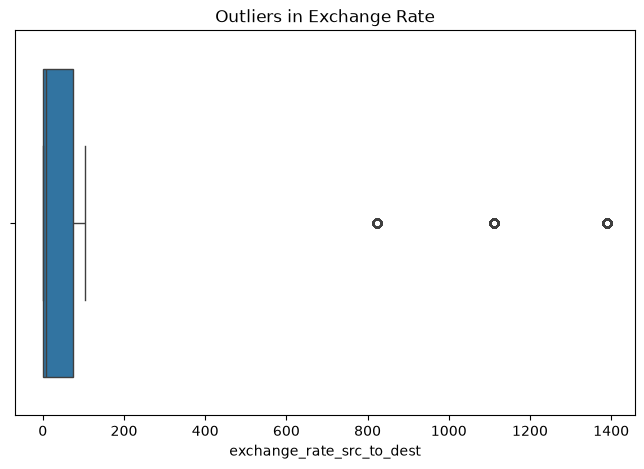

In [1613]:
# Visualize outliers in the 'exchange_rate_src_to_dest' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['exchange_rate_src_to_dest'])
plt.title("Outliers in Exchange Rate")
plt.show()

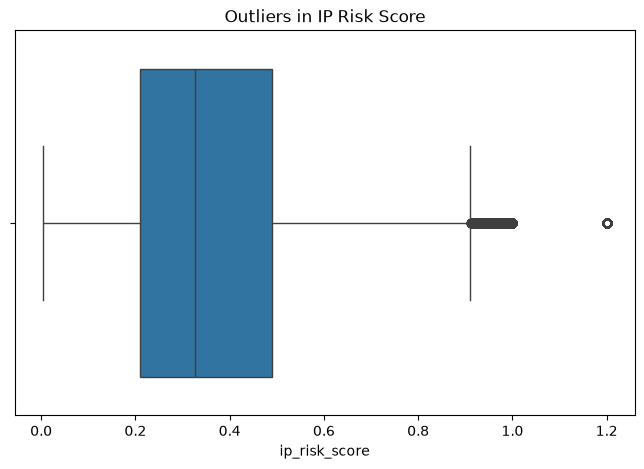

In [1614]:
# Visualize outliers in the 'device_trust_score' column using a boxplot     
plt.figure(figsize=(8,5))
sns.boxplot(x=df['ip_risk_score'])
plt.title("Outliers in IP Risk Score")
plt.show()

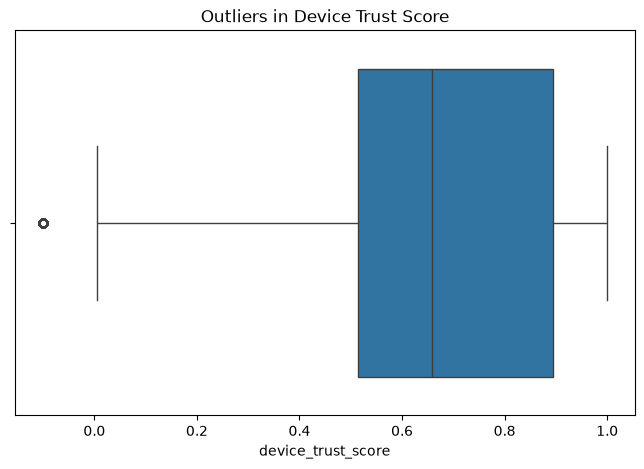

In [1615]:
# Visualize outliers in the 'device_trust_score' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['device_trust_score'])
plt.title("Outliers in Device Trust Score")
plt.show()

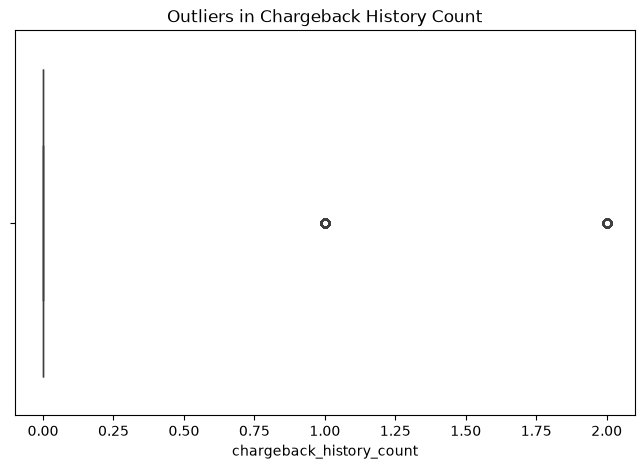

In [1616]:
# Visualize outliers in the 'chargeback_history_count' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['chargeback_history_count'])
plt.title("Outliers in Chargeback History Count")
plt.show()

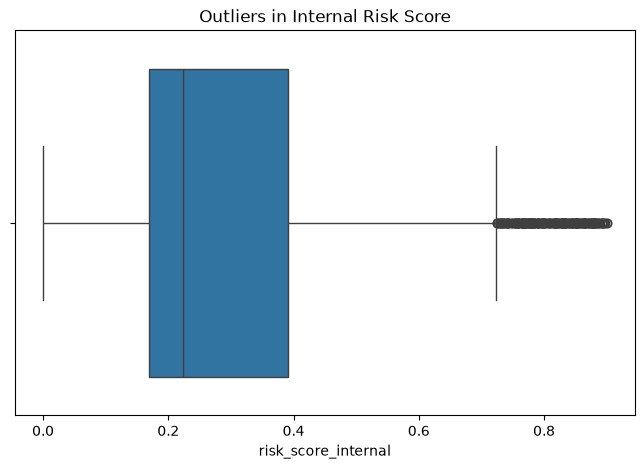

In [1617]:
# Visualize outliers in the 'risk_score_internal' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['risk_score_internal'])
plt.title("Outliers in Internal Risk Score")
plt.show()

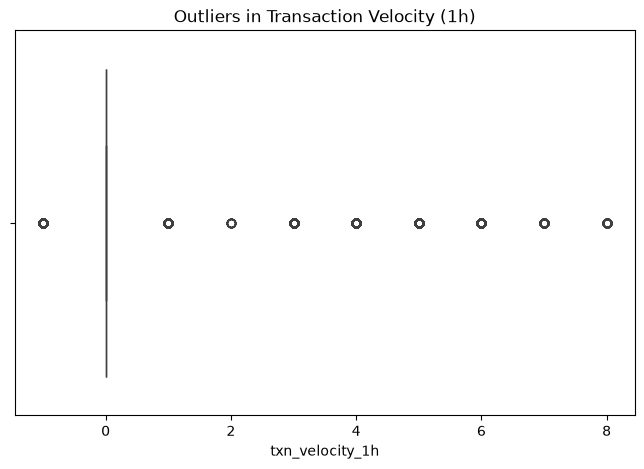

In [1618]:
# Visualize outliers in the 'txn_velocity_1h' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['txn_velocity_1h'])
plt.title("Outliers in Transaction Velocity (1h)")
plt.show()

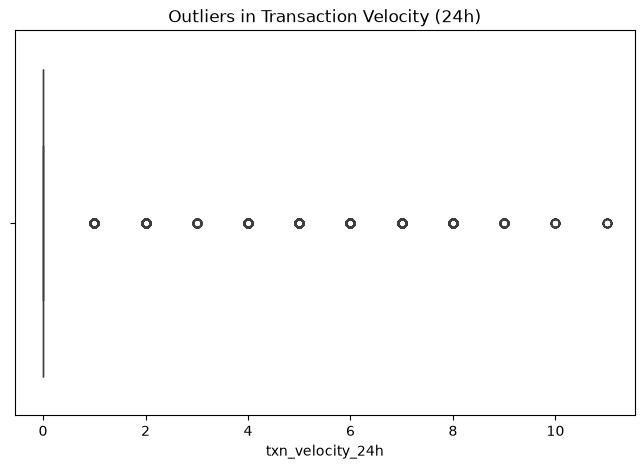

In [1619]:
# Visualize outliers in the 'txn_velocity_1h' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['txn_velocity_24h'])
plt.title("Outliers in Transaction Velocity (24h)")
plt.show()

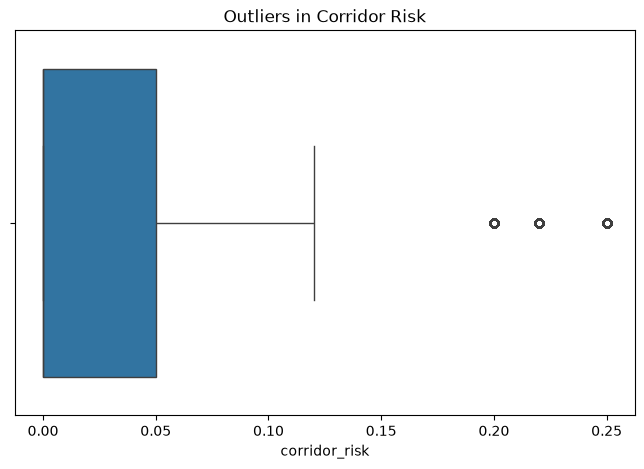

In [1620]:
# Visualize outliers in the 'corridor_risk' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['corridor_risk'])
plt.title("Outliers in Corridor Risk")
plt.show()

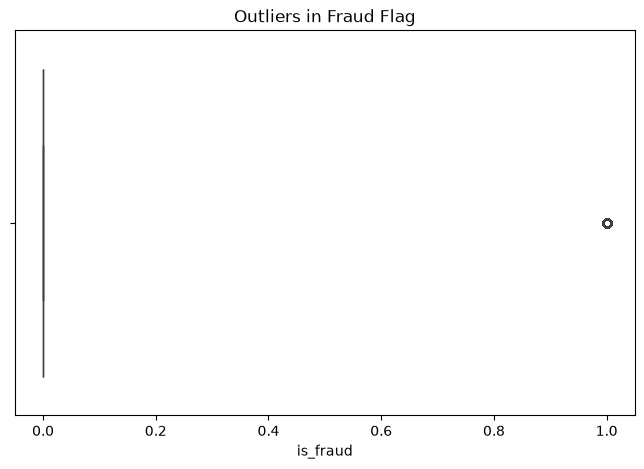

In [1621]:
# Visualize outliers in the 'is_fraud' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['is_fraud'])
plt.title("Outliers in Fraud Flag")
plt.show()

In [1622]:
# Display the shape of the DataFrame (number of rows and columns)
print("\nShape")
print(df.shape)


Shape
(10840, 45)


In [1623]:
# Display the distribution of the 'is_fraud' column to understand the balance of classes
print("\nFraud Distribution")
print(df['is_fraud'].value_counts())


Fraud Distribution
is_fraud
0    9854
1     986
Name: count, dtype: int64


In [1624]:
# Display the percentage of fraudulent transactions in the dataset
print("\nFraud Percentage")
print(df['is_fraud'].value_counts(normalize=True)*100)


Fraud Percentage
is_fraud
0    90.904059
1     9.095941
Name: proportion, dtype: float64


In [1625]:
# Convert the 'timestamp' column to datetime format, handling any errors by coercing invalid values to NaT (Not a Time)
df['timestamp'] = pd.to_datetime(
    df['timestamp'],
    errors='coerce'
)

In [1626]:
# Identify rows with invalid timestamps (NaT) and display their transaction IDs and timestamps
invalid_rows = df[df['timestamp'].isna()]
print(invalid_rows[['transaction_id', 'timestamp']])

Empty DataFrame
Columns: [transaction_id, timestamp]
Index: []


In [1627]:
# Drop rows with invalid timestamps to ensure a clean dataset for analysis
df = df.dropna(subset=['timestamp'])

In [1628]:
# Display the first 10 rows of the 'timestamp' column to verify the conversion to datetime format
print(df['timestamp'].head(10))

10232   2023-12-24 15:43:45.573611+00:00
10386   2024-04-12 02:12:31.573611+00:00
11314   2025-10-15 14:02:56.573611+00:00
10543   2024-07-14 22:19:08.573611+00:00
10539   2024-07-13 09:52:36.573611+00:00
10536   2024-07-11 06:03:27.573611+00:00
11355   2025-11-03 23:47:03.573611+00:00
10651   2024-09-14 07:50:14.573611+00:00
10632   2024-09-06 11:10:48.573611+00:00
10481   2024-06-04 18:46:53.573611+00:00
Name: timestamp, dtype: datetime64[us, UTC]


In [1629]:
# Display the first 5 rows of the 'timestamp' column
print(df['timestamp'].head(5))
print(df['timestamp'].sample(5))


10232   2023-12-24 15:43:45.573611+00:00
10386   2024-04-12 02:12:31.573611+00:00
11314   2025-10-15 14:02:56.573611+00:00
10543   2024-07-14 22:19:08.573611+00:00
10539   2024-07-13 09:52:36.573611+00:00
Name: timestamp, dtype: datetime64[us, UTC]
5787   2024-06-21 22:20:15.468549+00:00
6007   2024-07-17 14:54:44.468549+00:00
6771   2024-10-13 15:22:27.468549+00:00
3877   2023-12-05 05:32:10.468549+00:00
937    2023-01-16 22:25:45.468549+00:00
Name: timestamp, dtype: datetime64[us, UTC]


In [1630]:
# Display the data type of the 'timestamp' column to confirm it is in datetime format
print(df['timestamp'].dtype)

datetime64[us, UTC]


In [1631]:
# Extract datetime components
# Date
df['date'] = df['timestamp'].dt.date

# Time
df['time'] = df['timestamp'].dt.time

# Hour
df['hour'] = df['timestamp'].dt.hour

# Day of week (0=Monday)
df['day_of_week'] = df['timestamp'].dt.dayofweek

# Day name
df['day_name'] = df['timestamp'].dt.day_name()

# Month
df['month'] = df['timestamp'].dt.month

# Month name
df['month_name'] = df['timestamp'].dt.month_name()

# Quarter
df['quarter'] = df['timestamp'].dt.quarter

# Year
df['year'] = df['timestamp'].dt.year

# Weekend indicator
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)



In [1632]:
# Sort the DataFrame by 'customer_id' and 'timestamp' to prepare for time-based analysis
df = df.sort_values(['customer_id', 'timestamp'])



In [1633]:
# Create a new column 'transaction_number' that represents the sequential transaction number for each customer
df['transaction_number'] = (
    df.groupby('customer_id').cumcount() + 1
)


In [1634]:
# Create a new column 'transaction_number' that represents the sequential transaction number for each customer
df['transaction_number'] = (
    df.groupby('customer_id').cumcount() + 1
)


In [1635]:
# Calculate the time difference in minutes between consecutive transactions for each customer and store it in a new column 'minutes_since_last_txn'
df['minutes_since_last_txn'] = (
    df.groupby('customer_id')['timestamp']
      .diff()
      .dt.total_seconds()
      .div(60)
)


In [1636]:
# Fill missing values in the 'minutes_since_last_txn' column with 0, indicating that there was no previous transaction for those cases
df['minutes_since_last_txn'] = (
    df['minutes_since_last_txn'].fillna(0)
)


In [1637]:
# Fill missing values in the 'minutes_since_last_txn' column with 0, indicating that there was no previous transaction for those cases
df['minutes_since_last_txn'] = (
    df['minutes_since_last_txn'].fillna(0)
)


In [1638]:
# Create a new column 'device_frequency' that represents the number of transactions made from each device
df['device_frequency'] = (
    df.groupby('device_id')['device_id']
      .transform('count')
)


In [1639]:
# Create a new column 'ip_frequency' that represents the number of transactions made from each IP address
df['ip_frequency'] = (
    df.groupby('ip_address')['ip_address']
      .transform('count')
)


In [1640]:
# Create a new column 'customer_avg_amount' that represents the average transaction amount for each customer
df['customer_avg_amount'] = (
    df.groupby('customer_id')['amount_usd']
      .transform('mean')
)


In [1641]:
# Create a new column 'customer_max_amount' that represents the maximum transaction amount for each customer
df['customer_max_amount'] = (
    df.groupby('customer_id')['amount_usd']
      .transform('max')
)

In [1642]:
# Print a success message
print("New columns created successfully!")

print(df[['timestamp',
          'hour',
          'day_name',
          'month',
          'year',
          'is_weekend']].head())

New columns created successfully!
                             timestamp  hour   day_name  month  year  \
10232 2023-12-24 15:43:45.573611+00:00    15     Sunday     12  2023   
10386 2024-04-12 02:12:31.573611+00:00     2     Friday      4  2024   
11314 2025-10-15 14:02:56.573611+00:00    14  Wednesday     10  2025   
10543 2024-07-14 22:19:08.573611+00:00    22     Sunday      7  2024   
10539 2024-07-13 09:52:36.573611+00:00     9   Saturday      7  2024   

       is_weekend  
10232           1  
10386           0  
11314           0  
10543           1  
10539           1  


New features were created from the transaction timestamp to provide additional information about when each transaction occurred. These included the transaction date, time, hour, day of the week, day name, month, month name, quarter, year, and an indicator identifying whether the transaction occurred on a weekend. The dataset was then sorted by customer and transaction time to preserve the chronological order of transactions. Customer behavioural features were also generated, including the sequence number of each transaction, the time elapsed since the customer's previous transaction, the frequency of device and IP address usage, and each customer's average and maximum transaction amounts. These engineered features enrich the dataset by capturing temporal patterns and customer transaction behaviour, which can improve exploratory analysis and enhance the performance of fraud detection models.

    hour  is_fraud  Fraud Rate (%)
0      0  0.063736        6.373626
1      1  0.065327        6.532663
2      2  0.080685        8.068460
3      3  0.126819       12.681913
4      4  0.188755       18.875502
5      5  0.161426       16.142558
6      6  0.213823       21.382289
7      7  0.182628       18.262806
8      8  0.130064       13.006397
9      9  0.046620        4.662005
10    10  0.070485        7.048458
11    11  0.079625        7.962529
12    12  0.062222        6.222222
13    13  0.065646        6.564551
14    14  0.078947        7.894737
15    15  0.059701        5.970149
16    16  0.065646        6.564551
17    17  0.051044        5.104408
18    18  0.078723        7.872340
19    19  0.046653        4.665314
20    20  0.058957        5.895692
21    21  0.080189        8.018868
22    22  0.058691        5.869074
23    23  0.043933        4.393305


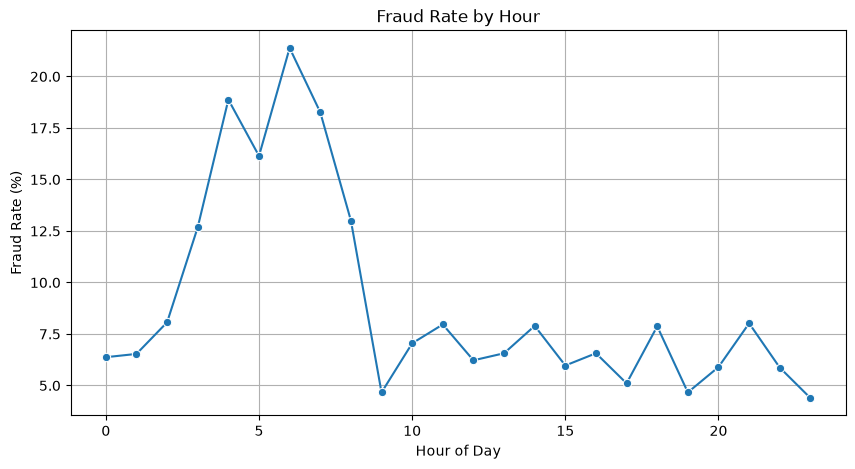

In [1643]:
# Analyze fraud rate by hour
fraud_hour = (
    df.groupby('hour')['is_fraud']
      .mean()
      .reset_index()
)

fraud_hour['Fraud Rate (%)'] = fraud_hour['is_fraud'] * 100
print(fraud_hour)

plt.figure(figsize=(10,5))
sns.lineplot(data=fraud_hour, x='hour', y='Fraud Rate (%)', marker='o')
plt.title('Fraud Rate by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.grid(True)
plt.show()

The fraud rate was calculated for each hour of the day to examine how fraudulent transactions vary over a 24-hour period. The results show the proportion and percentage of fraudulent transactions recorded during each hour, making it possible to identify periods with relatively higher or lower fraud activity. This analysis provides insight into the relationship between transaction time and fraud occurrence, helping to determine whether fraud is more likely to occur during specific hours of the day.

    day_name  is_fraud  Fraud Rate (%)
1     Monday  0.083333        8.333333
5    Tuesday  0.100577       10.057655
6  Wednesday  0.084757        8.475690
4   Thursday  0.098797        9.879671
0     Friday  0.087842        8.784214
2   Saturday  0.092338        9.233792
3     Sunday  0.088904        8.890374


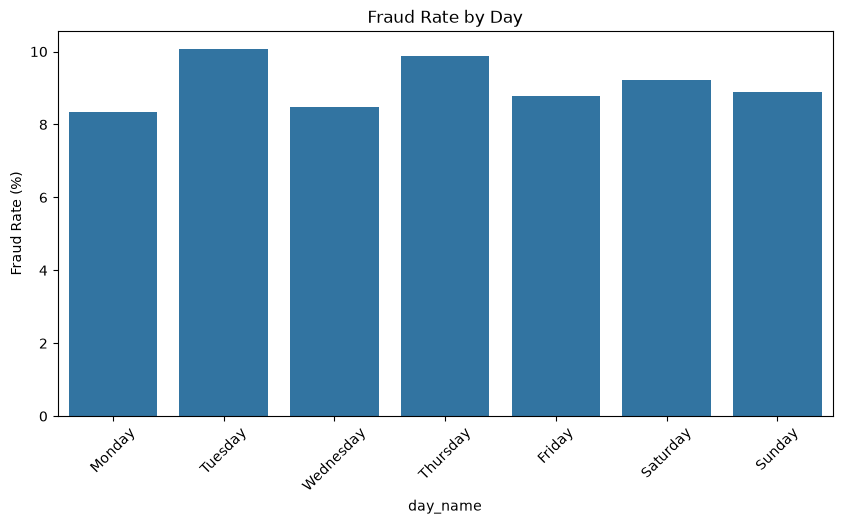

In [1644]:


# Analyze fraud rate by day of the week
fraud_day = (
    df.groupby('day_name')['is_fraud']
      .mean()
      .reset_index()
)

order = ['Monday','Tuesday','Wednesday','Thursday',
         'Friday','Saturday','Sunday']

fraud_day['day_name'] = pd.Categorical(
    fraud_day['day_name'],
    categories=order,
    ordered=True
)

# Sort the DataFrame by 'day_name' to ensure the days are in the correct order for visualization

fraud_day = fraud_day.sort_values('day_name')
fraud_day['Fraud Rate (%)'] = fraud_day['is_fraud']*100


print(fraud_day)

plt.figure(figsize=(10,5))
sns.barplot(data=fraud_day,x='day_name',y='Fraud Rate (%)')
plt.xticks(rotation=45)
plt.title("Fraud Rate by Day")
plt.show()

The fraud rate was analyzed for each day of the week to determine whether fraudulent transactions were more common on certain days. The analysis calculated the proportion and percentage of fraudulent transactions for each weekday, allowing for a comparison of fraud patterns across the week. This provides insight into whether the likelihood of fraud changes depending on the day on which a transaction occurs.

In [ ]:
# Analyze fraud rate by month
# Remove leading/trailing spaces
df['channel'] = df['channel'].str.strip()

# Convert to lowercase
df['channel'] = df['channel'].str.lower()

# Correct spelling mistakes and inconsistent values
df['channel'] = df['channel'].replace({
    'weeb': 'web',
    'mobille': 'mobile'
})

# Check the cleaned values
print(df['channel'].value_counts())

channel
mobile     6167
web        3669
atm         968
unknown      36
Name: count, dtype: int64


   channel  is_fraud  Fraud Rate (%)
0      web  0.166530       16.653039
1      atm  0.082645        8.264463
2   mobile  0.047673        4.767310
3  unknown  0.027778        2.777778


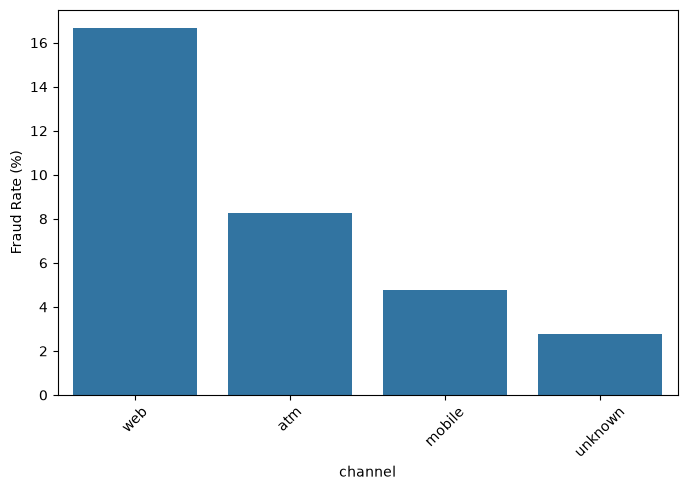

In [1662]:
# Analyze fraud rate by channel
fraud_channel = (
    df.groupby('channel')['is_fraud']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

fraud_channel['Fraud Rate (%)'] = fraud_channel['is_fraud']*100

print(fraud_channel)

plt.figure(figsize=(8,5))
sns.barplot(data=fraud_channel,
            x='channel',
            y='Fraud Rate (%)')

plt.xticks(rotation=45)
plt.show()

The fraud rate was analyzed across the different transaction channels to examine whether the method used to perform a transaction is associated with fraudulent activity. The analysis calculated the proportion and percentage of fraudulent transactions for each channel, enabling a comparison of fraud occurrence across web, ATM, mobile, and other transaction methods.

In [1691]:
# Remove leading and trailing spaces
df['home_country'] = df['home_country'].str.strip()

# Convert all values to uppercase
df['home_country'] = df['home_country'].str.upper()

# Correct any spelling mistakes (if they exist)
df['home_country'] = df['home_country'].replace({
    'UNKNOWN': 'UNKNOWN',
    'UK': 'UK',
    'US': 'US',
    'CA': 'CA'
})

# Check the cleaned values
print(df['home_country'].value_counts())

home_country
US         7599
UK         2026
CA         1183
UNKNOWN      32
Name: count, dtype: int64


  home_country  is_fraud  Fraud Rate (%)
0           CA  0.156382       15.638208
1           UK  0.136723       13.672261
2           US  0.068825        6.882485
3      UNKNOWN  0.031250        3.125000


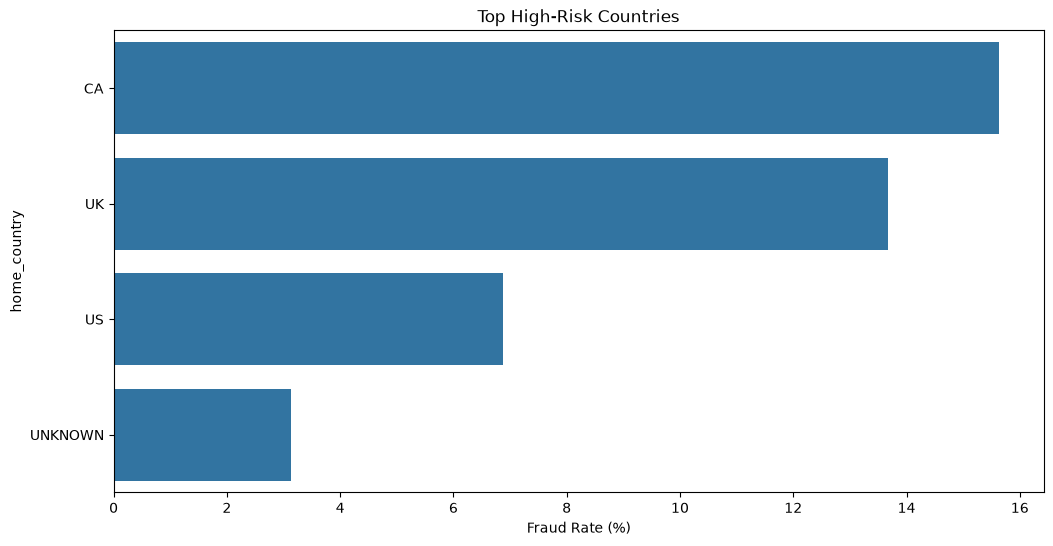

In [ ]:
# Analyze fraud rate by home country
fraud_country = (
    df.groupby('home_country')['is_fraud']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

fraud_country['Fraud Rate (%)'] = fraud_country['is_fraud']*100

print(fraud_country.head(15))

plt.figure(figsize=(12,6))
sns.barplot(
    data=fraud_country.head(15),
    x='Fraud Rate (%)',
    y='home_country'
)
plt.title("Top High-Risk Countries")
plt.show()

The fraud rate was analyzed according to the customers' home country to determine whether the likelihood of fraudulent transactions differs across countries. The analysis calculated the proportion and percentage of fraudulent transactions for each country, allowing for comparisons of fraud occurrence among different customer locations.

is_fraud            0          1
new_device                      
False       95.020442   4.979558
True        60.722521  39.277479


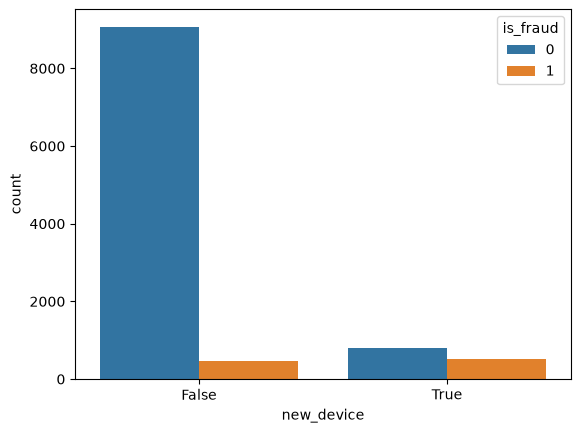

In [ ]:
# Analyze fraud rate by new device
fraud_device = pd.crosstab(
    df['new_device'],
    df['is_fraud'],
    normalize='index'
)*100

print(fraud_device)

sns.countplot(
    data=df,
    x='new_device',
    hue='is_fraud'
)
plt.show()

is_fraud                   0          1
location_mismatch                      
False              96.366247   3.633753
True               63.213886  36.786114


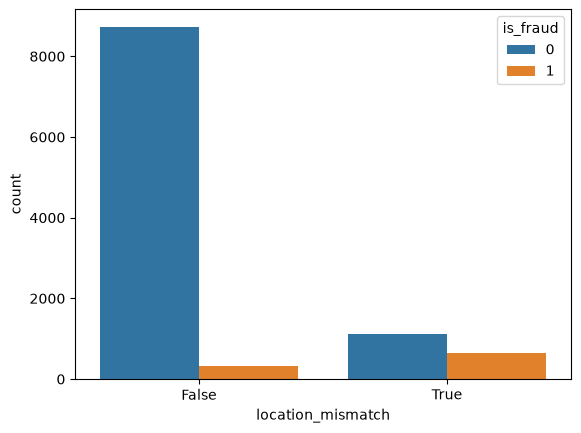

In [1694]:
# Analyze fraud rate by location mismatch
fraud_location = pd.crosstab(
    df['location_mismatch'],
    df['is_fraud'],
    normalize='index'
)*100

print(fraud_location)

sns.countplot(
    data=df,
    x='location_mismatch',
    hue='is_fraud'
)
plt.show()

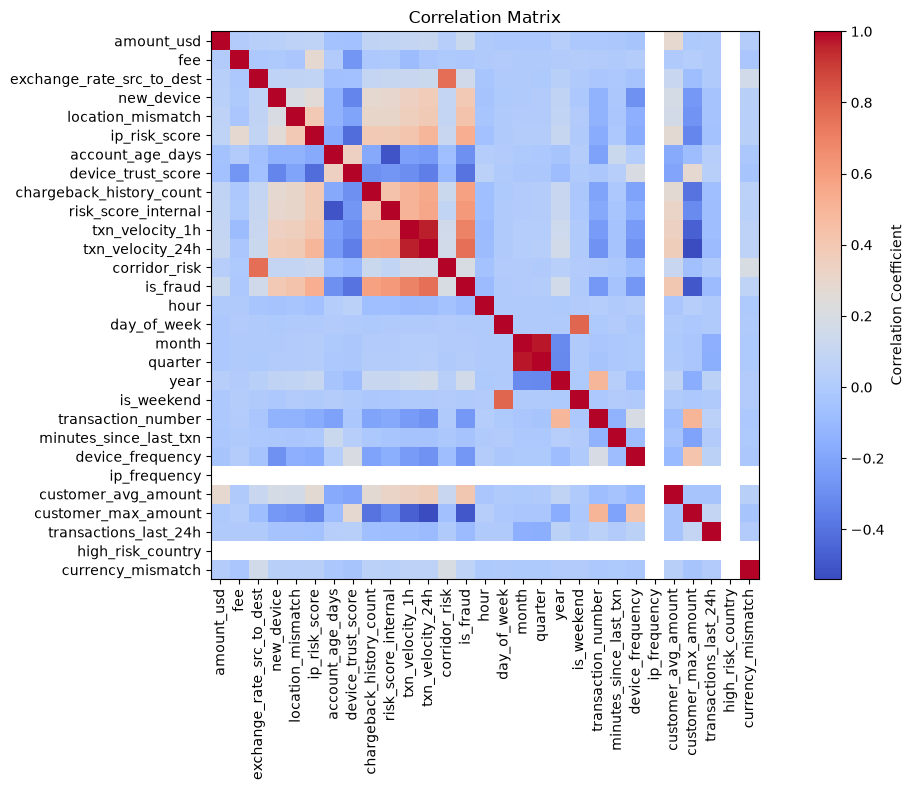

In [1695]:

# Compute the correlation matrix
pf = df.corr(numeric_only=True)

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
plt.imshow(pf, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation Coefficient')

plt.xticks(range(len(pf.columns)), pf.columns, rotation=90)
plt.yticks(range(len(pf.columns)), pf.columns)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

A correlation analysis was performed on the numerical variables in the dataset to examine the strength and direction of the relationships between them. The resulting correlation matrix was visualized using a heatmap, where different colors represent positive, negative, or weak correlations between pairs of variables. This analysis helps to identify variables that are highly related, detect potential multicollinearity, and understand how different numerical features are associated with one another before conducting further statistical analysis or developing fraud detection models.

In [1696]:
# Create a new column 'transactions_last_24h' that represents the number of transactions made by each customer in the last 24 hours
df = df.sort_values(['customer_id','timestamp'])

df['transactions_last_24h'] = (
    df.groupby('customer_id')
      .rolling('1D', on='timestamp')['transaction_id']
      .count()
      .reset_index(drop=True)
)

print(df[['customer_id',
          'timestamp',
          'transactions_last_24h']].head())

                                customer_id                        timestamp  \
10232  0006f893-10a8-4235-831b-fcae1e3f0140 2023-12-24 15:43:45.573611+00:00   
10386  00147b79-11ed-4f8f-a3af-651778b78dd3 2024-04-12 02:12:31.573611+00:00   
11314  00668d83-6f9f-4401-9a0f-04f94140abb6 2025-10-15 14:02:56.573611+00:00   
10543  00957a15-945f-4bfb-b5fc-d867cbaee95d 2024-07-14 22:19:08.573611+00:00   
10539  00ab675d-a6ea-4d6e-bcdf-79027ce4f944 2024-07-13 09:52:36.573611+00:00   

       transactions_last_24h  
10232                    1.0  
10386                    1.0  
11314                    NaN  
10543                    1.0  
10539                    1.0  


In [1697]:
# Create a new column 'minutes_since_last_txn' that represents the time elapsed since the last transaction for each customer
df['minutes_since_last_txn'] = (
    df.groupby('customer_id')['timestamp']
      .diff()
      .dt.total_seconds()/60
)

df['minutes_since_last_txn'] = (
    df['minutes_since_last_txn']
      .fillna(0)
)

print(df[['customer_id',
          'minutes_since_last_txn']].head())

                                customer_id  minutes_since_last_txn
10232  0006f893-10a8-4235-831b-fcae1e3f0140                     0.0
10386  00147b79-11ed-4f8f-a3af-651778b78dd3                     0.0
11314  00668d83-6f9f-4401-9a0f-04f94140abb6                     0.0
10543  00957a15-945f-4bfb-b5fc-d867cbaee95d                     0.0
10539  00ab675d-a6ea-4d6e-bcdf-79027ce4f944                     0.0


In [1698]:
# Create a new column 'device_frequency' that represents the number of transactions made from each device
df['device_frequency'] = (
    df.groupby('device_id')['device_id']
      .transform('count')
)

print(df[['device_id',
          'device_frequency']].head())

                                  device_id  device_frequency
10232  609547e5-d0f9-4a82-bbda-29a503788d0b                 1
10386  1fe01c85-189b-4c49-a0c9-0e8f98fe1d80                 1
11314  113f3ae6-3670-4594-a672-0eec0a44c357                 1
10543  59639db6-5600-4607-8f55-9b09db5b7f8f                 1
10539  76cd2a3b-3659-4f2c-b1c9-22717bebec13                 1


In [1699]:
# Identify the top 10 devices by transaction frequency
top_devices = (
    df.groupby('device_id')
      .size()
      .sort_values(ascending=False)
      .head(10)
)

print(top_devices)

device_id
e70db499-19e1-4927-b04f-3ebfcf62e33c    81
9849347e-5774-4f24-ac70-de0c98536adf    71
1d8d6841-8816-4c1a-9c03-cda94a9516ae    70
9957de24-ace9-4938-bb81-6e7e41276961    70
917faeeb-252b-4379-8ba3-8c4bae9791fb    69
155f2330-d8da-4ca2-80c7-746334918b3f    68
645cfb3b-40db-489f-96d2-e8f372001668    63
ecf86eb0-ca14-4e1c-905c-3134d0a3a647    61
83e59adf-19af-485d-b21b-89e513f132c2    60
793ba2dc-4410-46c8-81d7-78a44b268612    55
dtype: int64


In [1700]:
# Create a new column 'ip_frequency' that represents the number of transactions made from each IP address
df['ip_frequency'] = (
    df.groupby('ip_address')['ip_address']
      .transform('count')
)

print(df[['ip_address',
          'ip_frequency']].head())

            ip_address  ip_frequency
10232  116.251.123.215             1
10386  174.180.121.174             1
11314  137.192.143.158             1
10543    57.144.100.75             1
10539    223.180.139.8             1


In [1701]:
# Create a new DataFrame 'customer_history' that aggregates transaction data for each customer, including the total number of transactions, total amount spent, average transaction amount, and fraud rate
customer_history = (
    df.groupby('customer_id')
      .agg(
          Transactions=('transaction_id','count'),
          Total_Amount=('amount_usd','sum'),
          Average_Amount=('amount_usd','mean'),
          Fraud_Rate=('is_fraud','mean')
      )
)

print(customer_history.head())

                                      Transactions  Total_Amount  \
customer_id                                                        
0006f893-10a8-4235-831b-fcae1e3f0140             1        540.09   
00147b79-11ed-4f8f-a3af-651778b78dd3             1        286.04   
00668d83-6f9f-4401-9a0f-04f94140abb6             1         99.21   
00957a15-945f-4bfb-b5fc-d867cbaee95d             1       2730.91   
00ab675d-a6ea-4d6e-bcdf-79027ce4f944             1        146.36   

                                      Average_Amount  Fraud_Rate  
customer_id                                                       
0006f893-10a8-4235-831b-fcae1e3f0140          540.09         1.0  
00147b79-11ed-4f8f-a3af-651778b78dd3          286.04         1.0  
00668d83-6f9f-4401-9a0f-04f94140abb6           99.21         0.0  
00957a15-945f-4bfb-b5fc-d867cbaee95d         2730.91         1.0  
00ab675d-a6ea-4d6e-bcdf-79027ce4f944          146.36         0.0  


Customer-level transaction behavior was summarized by grouping the dataset according to customer ID. For each customer, the total number of transactions, total transaction amount, average transaction amount, and fraud rate were calculated. This analysis provides an overview of individual customer transaction patterns and helps identify customers with higher transaction activity, larger transaction values, or a greater proportion of fraudulent transactions, which can be useful for understanding customer behavior and detecting potential fraud risks.

In [1702]:
# Create a new column 'high_risk_country' that indicates whether the customer's home country is considered high risk based on the fraud rate
country_risk = (
    df.groupby('home_country')['is_fraud']
      .mean()
)

threshold = 0.20

high_risk = country_risk[country_risk > threshold].index

df['high_risk_country'] = (
    df['home_country']
      .isin(high_risk)
      .astype(int)
)

print(df[['home_country',
          'high_risk_country']].head())

      home_country  high_risk_country
10232           CA                  0
10386           US                  0
11314           US                  0
10543           UK                  0
10539           US                  0


In [1703]:
# Create a new column 'currency_mismatch' that indicates whether the source and destination currencies are different
df['currency_mismatch'] = (
    df['source_currency'] != df['dest_currency']
).astype(int)

print(df[['source_currency',
          'dest_currency',
          'currency_mismatch']].head())

      source_currency dest_currency  currency_mismatch
10232             CAD           PHP                  1
10386             USD           MXN                  1
11314             USD           USD                  0
10543             GBP           NGN                  1
10539             USD           PHP                  1


In [1704]:
# Analyze fraud rate by currency mismatch
pd.crosstab(
    df['currency_mismatch'],
    df['is_fraud'],
    normalize='index'
)*100

is_fraud,0,1
currency_mismatch,,
0,96.394984,3.605016
1,90.171476,9.828524


In [1705]:
# Analyze fraud rate by currency mismatch
customer_avg = (
    df.groupby('customer_id')['amount_usd']
      .mean()
      .reset_index()
)
# Rename the columns of the 'customer_avg' DataFrame for clarity
customer_avg.columns = [
    'customer_id',
    'average_transaction_amount'
]

print(customer_avg.head())

                            customer_id  average_transaction_amount
0  0006f893-10a8-4235-831b-fcae1e3f0140                      540.09
1  00147b79-11ed-4f8f-a3af-651778b78dd3                      286.04
2  00668d83-6f9f-4401-9a0f-04f94140abb6                       99.21
3  00957a15-945f-4bfb-b5fc-d867cbaee95d                     2730.91
4  00ab675d-a6ea-4d6e-bcdf-79027ce4f944                      146.36
